In [ ]:
import datetime as dt

import contextily as cx
import geopandas as gpd
import pandas as pd
import xarray as xr
from meteora import clients, utils

In [ ]:
spatial_extent_filepath = "../data/processed/zurich-extent.gpkg"

# study period (e.g., JJA)
# # reference data to get study period
# ref_ts_df_filepath = "../data/raw/parallel-2025-int.csv"
# year = 2025
start_year = 2023
end_year = 2024
start_month = 6
end_month = 8

# requested variables
variables = ["temperature", "radiation_shortwave"]

# output files
dst_ts_cube_filepath = "../data/interim/zurich-aws-ts-cube.nc"
# dst_stations_gdf_filepath = "../data/interim/zurich-aws-stations.gpkg"

In [ ]:
region_gser = gpd.read_file(spatial_extent_filepath)

In [ ]:
client = clients.MeteoSwissClient(region_gser)

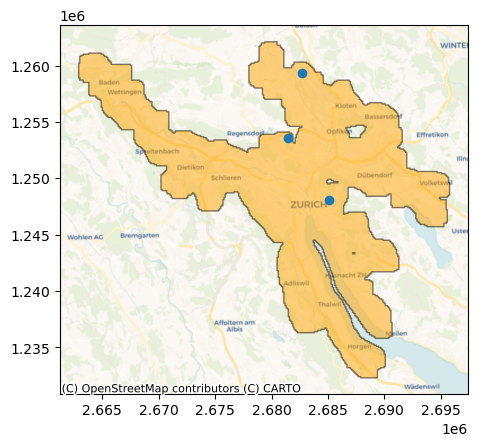

In [ ]:
ax = region_gser.plot(color="orange", edgecolor="k", alpha=0.5)
client.stations_gdf.plot(ax=ax, legend=True)
cx.add_basemap(ax, crs=region_gser.crs, source=cx.providers.CartoDB.Voyager)

In [ ]:
# # read reference data to get study period
# ref_ts_df = pd.read_csv(ref_ts_df_filepath, parse_dates=["time"]).set_index("time")

# # get data for study period
# ts_df = (
#     utils.long_to_wide(
#         pd.concat(
#             [
#                 client.get_ts_df(variables, ref_ts_df.index[0], ref_ts_df.index[-1])
#                 for client in client_dict.values()
#                 if len(client.stations_gdf) >= 1
#             ]
#         )
#     )
#     .dropna(how="all", axis="columns")
#     .resample("h")
#     .mean()
# )
ts_df = pd.concat(
    [
        client.get_ts_df(
            # "temperature",
            variables,
            # pd.Timestamp(start),
            # dt.datetime.combine(
            #     pd.Timestamp(end),
            #     dt.time.max,
            # ),
            dt.date(year, start_month, 1),
            # get latest moment of the latest day of the month
            # ACHTUNG: this won't work if `end_month` is 12 (see commented code
            # below)
            dt.datetime.combine(
                dt.date(year, end_month + 1, 1) - dt.timedelta(days=1),
                dt.time.max,
            ),
        )
        for year in range(start_year, end_year + 1)
    ]
)
ts_df.head()

temperature  radiation_shortwave
station_id time                                                 
KLO        2023-06-01 00:00:00         11.8                  2.0
           2023-06-01 00:10:00         12.0                  2.0
           2023-06-01 00:20:00         14.1                  0.0
           2023-06-01 00:30:00         12.4                  1.0
           2023-06-01 00:40:00         11.6                  3.0

In [ ]:
ts_cube = utils.long_to_cube(ts_df, client.stations_gdf)
# note that we need to resample each year data before concat
# otherwise resample would add nan coords for all the missing non-JJA data
ts_cube = xr.concat(
    [
        group_cube.resample(**{"time": "h"}).mean()
        for _, group_cube in ts_cube.groupby(ts_cube["time"].dt.year)
    ],
    dim="time",
)
ts_cube

<xarray.Dataset> Size: 247kB
Dimensions:              (time: 4416, geometry: 3)
Coordinates:
  * time                 (time) datetime64[ns] 35kB 2023-06-01 ... 2024-08-31...
  * geometry             (geometry) geometry 24B POINT (2682711 1259339) ... ...
    station_id           (geometry) object 24B 'KLO' 'REH' 'SMA'
Data variables:
    temperature          (time, geometry) float64 106kB 12.42 13.28 ... 20.73
    radiation_shortwave  (time, geometry) float64 106kB 1.5 0.8333 ... 1.167 0.0
Indexes:
    geometry  GeometryIndex (crs=EPSG:2056)

In [ ]:
# plot_ts_df = ts_df.stack().rename("temperature").reset_index()
# sns.lineplot(
#     data=plot_ts_df.assign(**{"hour": plot_ts_df["time"].dt.hour}),
#     x="hour",
#     y="temperature",
#     hue="heatwave",
# )

In [ ]:
# save the time series of measurements to a file
# ts_df.to_csv(dst_ts_df_filepath)
# save the stations' locations to a file
# client.stations_gdf.to_file(dst_stations_gdf_filepath)
ts_cube.xvec.encode_cf().to_netcdf(dst_ts_cube_filepath, mode="w")

/home/martibosch/data-science/swiss-lcd-heatwaves/.pixi/envs/default/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(
